# Feedstock application and re-application

This notebook walks through how feedstock gets added to a MIN3P soil profile, either for the first or Nth time. Functions here are prototypes for the feedstock.py byte_util.

In `fs_timing_rxn` we compare two rock-application schedules:

| scenario | schedule |
|---|---|
| `pulse`  | 10 t/ha in year 1, nothing after |
| `annual` | 1 t/ha/yr for 10 years |

Both are run as ten chained 1-year MIN3P simulations, where each year restarts from the previous year's final state. `annual` needs fresh rock mixed in at nine of those restarts, on top of whatever is left of the earlier applications. That mixing of new and old rock is what this notebook focuses on.

**Key constraints**

1. **Runs the same on UNLV cluster and Coiled.** Mostly means we don't bake in S3 anywhere.
2. **Multi-mineral feedstocks.** A feedstock is defined by a file listing mineral names and weight percents. Forsterite is a one-row case.

**Sections**

1. Mineral properties (from the MIN3P database)
2. Defining a feedstock from a file
3. Feedstock -> volume fraction and surface area
4. Distributing fs over the depth grid
5. Validation: reproduce the committed year-1 ERW files
6. **Re-application onto a partially dissolved profile**
7. Multi-mineral example

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

from min3p.output import read_min3p

# Resolve the repo root by walking up to the directory holding pyproject.toml, so the
# notebook works wherever it is
def find_repo_root(start=None):
    p = (Path(start) if start else Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand / "pyproject.toml").exists() and (cand / "simulations").is_dir():
            return cand
    raise FileNotFoundError("could not locate repo root from %s" % p)

REPO = find_repo_root()
DBS_DIR    = REPO / "simulations" / "databases"
RXN_RUNS   = REPO / "simulations" / "met_forcing_rxn" / "min3p_runs"
FEEDSTOCKS = REPO / "input_data" / "feedstocks"
SCHEDULES  = REPO / "input_data" / "application_schedules"

# The committed year-1 ERW run we validate against.
REF_RUN = RXN_RUNS / "Cecil" / "longterm_erw"

print("repo root:", REPO)
print("reference run exists:", REF_RUN.is_dir())

repo root: /Users/tylerkukla/Documents/GitHub/min3p-model-bytes
reference run exists: True


### Plot styling

In [18]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# Validated 3-slot categorical palette + ink tokens
CAT = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781", "grid": "#e6e5e0"}
SURFACE = "#fcfcfb"

def label_line(ax, x, y, text, color, dx=4, dy=0, ha="left", va="center"):
    """Direct-label a series at a point, in ink rather than the series colour."""
    ax.annotate(text, xy=(x, y), xytext=(dx, dy), textcoords="offset points",
                color=color, fontsize=8, ha=ha, va=va, fontweight="medium")


def depth_axis(ax, max_depth_cm=40):
    """Configure a soil-profile y-axis: depth in cm, increasing downward."""
    ax.set_ylim(max_depth_cm, 0)
    # ax.grid(True, axis="both", alpha=0.7)
    ax.set_axisbelow(True)


def as_depth_cm(z):
    """Convert MIN3P elevation to depth below ground in cm."""
    return (np.asarray(z).max() - np.asarray(z)) * 100

---
## 1. Mineral properties, read from the MIN3P database

Use MIN3P mineral database as source of truth for mineral molar masses / densities, etc.

Any entry has:

```
'forst-ph'
'surface'
 140.6931    3.2000
 3  'h+1'   -4.000  'mg+2'    2.000  'h4sio4'    1.000    'ftr'   0.00001
'reversible'  -28.2980  48.5100
```

Line 3 is **molar mass (g/mol)** and **density (g/cm3)**, so molar volume follows as `molar_mass / density`. Reading from the database means the feedstock calculation can't disagree with the thermodynamics MIN3P is actually integrating.

In [3]:
def read_mineral_database(dbs_path):
    """Parse molar mass and density for every mineral in a MIN3P `mineral.dbs`.

    Parameters
    ----------
    dbs_path : str or pathlib.Path
        Path to the MIN3P mineral database file.

    Returns
    -------
    dict
        Maps mineral name -> dict with 'molar_mass_g_mol', 'density_g_cm3' and
        'molar_volume_cm3_mol'.
    """
    lines = Path(dbs_path).read_text(errors="replace").splitlines()
    minerals = {}
    for i, line in enumerate(lines):
        name = line.strip()
        # A mineral entry is a quoted name, followed by a surface-area-type line,
        # followed by the "molar mass  density" line.
        if not (name.startswith("'") and name.endswith("'") and len(name) > 2):
            continue
        if i + 2 >= len(lines) or lines[i + 1].strip() != "'surface'":
            continue
        parts = lines[i + 2].split()
        try:
            molar_mass, density = float(parts[0]), float(parts[1])
        except (ValueError, IndexError):
            continue
        minerals[name.strip("'")] = {
            "molar_mass_g_mol": molar_mass,
            "density_g_cm3": density,
            "molar_volume_cm3_mol": molar_mass / density,
        }
    return minerals


mineral_db = read_mineral_database(DBS_DIR / "mineral.dbs")
print(f"parsed {len(mineral_db)} minerals from mineral.dbs\n")

deck_minerals = ["quartz", "k-feld-d-ph", "na-montmor", "calcite-ph",
                 "sio2(a,pt)", "gibbsite-ph", "forst-ph"]
pd.DataFrame(mineral_db).T.loc[deck_minerals].round(4)

parsed 599 minerals from mineral.dbs



,molar_mass_g_mol,density_g_cm3,molar_volume_cm3_mol
quartz,60.0848,2.650,22.6735
k-feld-d-ph,278.3315,2.570,108.3002
na-montmor,367.2200,2.741,133.9730
calcite-ph,100.0894,2.710,36.9334
"sio2(a,pt)",60.0848,2.650,22.6735
gibbsite-ph,78.0037,2.350,33.1931
forst-ph,140.6931,3.200,43.9666


### Cross-check against the hardcoded values

Two things worth knowing before we build on top of `byte_util.reaction.mineral_params`:

In [4]:
from byte_util.reaction import mineral_params

rows = []
for m in deck_minerals:
    rows.append({
        "mineral": m,
        "rho_mineral_params": mineral_params[m]["density"],
        "rho_mineral_dbs": mineral_db[m]["density_g_cm3"],
    })
check = pd.DataFrame(rows).set_index("mineral")
check["agrees"] = np.isclose(check["rho_mineral_params"], check["rho_mineral_dbs"], rtol=1e-3)
check

,rho_mineral_params,rho_mineral_dbs,agrees
mineral,,,
quartz,2.65,2.650,True
k-feld-d-ph,2.57,2.570,True
na-montmor,2.74,2.741,True
calcite-ph,2.71,2.710,True
"sio2(a,pt)",2.65,2.650,True
gibbsite-ph,2.35,2.350,True
forst-ph,3.20,3.200,True


---
## 2. Defining a feedstock from a file

A feedstock is a CSV with one row per mineral:

```
mineral,weight_percent
forst-ph,100.0
```

Rules:

- `mineral` must be a **MIN3P mineral name**, consistent across the .dbs and the minerals block of the `.dat` deck.
- `weight_percent` is renormalised to sum to 100, so you can enter unnormalised values.
- `diameter_um` is optional per-mineral; it falls back to the feedstock-wide default. 

**Bulk feedstock density is derived** from the mass-weighted harmonic mean of the components.

$$\frac{1}{\rho_{fs}} = \sum_i \frac{w_i}{\rho_i}$$

which for a single mineral collapses to that mineral's own density and ensures per-mineral vol fracs sum to 1.

In [5]:
def load_feedstock(path, mineral_db, default_diameter_um, density_g_cm3=None):
    """Load a feedstock definition file and join it to mineral database properties.

    Parameters
    ----------
    path : str or pathlib.Path
        CSV with columns `mineral`, `weight_percent` and optionally `diameter_um`.
        Lines beginning with `#` are treated as comments.
    mineral_db : dict
        Output of `read_mineral_database`.
    default_diameter_um : float
        Grain diameter applied to any mineral without its own `diameter_um`.
    density_g_cm3 : float, optional
        Bulk feedstock density. Derived from the composition when not given.

    Returns
    -------
    feedstock : pandas.DataFrame
        One row per mineral with weight fraction and molar properties.
    density_g_cm3 : float
        Bulk density of the feedstock (g/cm3).
    """
    feedstock = pd.read_csv(path, comment="#")

    missing_cols = {"mineral", "weight_percent"} - set(feedstock.columns)
    if missing_cols:
        raise ValueError(f"{path} is missing required column(s): {sorted(missing_cols)}")

    unknown = sorted(set(feedstock["mineral"]) - set(mineral_db))
    if unknown:
        raise KeyError(f"minerals not found in the MIN3P database: {unknown}")

    # Renormalise so weight fractions sum to 1
    feedstock["wt_frac"] = feedstock["weight_percent"] / feedstock["weight_percent"].sum()

    for key in ("molar_mass_g_mol", "density_g_cm3", "molar_volume_cm3_mol"):
        feedstock[key] = [mineral_db[m][key] for m in feedstock["mineral"]]

    if "diameter_um" not in feedstock.columns:
        feedstock["diameter_um"] = np.nan
    feedstock["diameter_um"] = feedstock["diameter_um"].fillna(default_diameter_um)

    # Bulk density: mass-weighted harmonic mean of the components
    if density_g_cm3 is None:
        density_g_cm3 = 1.0 / (feedstock["wt_frac"] / feedstock["density_g_cm3"]).sum()

    return feedstock, density_g_cm3


forsterite, forsterite_density = load_feedstock(
    FEEDSTOCKS / "forsterite.csv", mineral_db, default_diameter_um=50.0
)
print(f"derived bulk feedstock density: {forsterite_density:.4f} g/cm3")
forsterite

derived bulk feedstock density: 3.2000 g/cm3


,mineral,weight_percent,wt_frac,molar_mass_g_mol,density_g_cm3,molar_volume_cm3_mol,diameter_um
0,forst-ph,100.0,1.0,140.6931,3.2,43.966594,50.0


---
## 3. Feedstock -> volume fraction and bulk surface area

Three steps:

**(a) How much rock per unit soil volume.** An application rate in t/ha becomes a volume fraction based on fs density and mixing depth:

$$\phi_{\text{app}} = \frac{R\,[\text{t/ha}] \times 10^{-1}}{\rho_{fs}\,[\text{kg/m}^3] \times d_{\text{till}}\,[\text{m}]}$$

**(b) Split across minerals.** Each mineral's share of the feedstock *volume* is
`wt_frac / rho_i * rho_fs`, and its volume fraction in soil is that times $\phi_{\text{app}}$.

**(c) Surface area.** Geometric specific surface area of a sphere, scaled by a roughness factor:

$$\text{SSA} = \frac{6}{\rho\,d}\,\times\,\text{rf}$$

then converted to the **bulk** surface area MIN3P wants in `.surf` — m2 per litre of soil:

$$\text{BSA}\,[\text{m}^2/\text{L}] = \text{SSA}\,[\text{m}^2/\text{g}] \times \rho\,[\text{g/cm}^3] \times 1000 \times \phi$$

Note the unit change: the existing notebook works in m2/m3 soil, but `.surf` files are m2/L (factor 1000 diff).

### Roughness factor

The roughness factor is a **user choice**, defaulting to a constant of 10. Either give a number directly, or name one of the grain-size-dependent calibrations carried over from `MIN3P_CalculateFeedstockApplication.ipynb`:

| option | formula (r = grain radius, m) |
|---|---|
| `smooth` | 1.0 |
| `constant` | whatever you pass as `const_rf` (**default**, 10) |
| `NSB07` | 20.0 |
| `BM00` | 10^0.7 · r^(−0.1) |
| `B20` | 10^3.3 · r^0.33 |


In [6]:
DEFAULT_ROUGHNESS_OPTION = "constant"
DEFAULT_CONST_RF = 10.0


def feedstock_roughness(option=DEFAULT_ROUGHNESS_OPTION, radius_m=None,
                        const_rf=DEFAULT_CONST_RF):
    """Roughness factor (dimensionless) for a grain of the given radius.

    Parameters
    ----------
    option : str or float
        'smooth', 'constant', 'NSB07', 'BM00', 'B20', or a number used directly.
        Defaults to 'constant'.
    radius_m : float, optional
        Grain radius (m). Required only for the size-dependent calibrations
        ('BM00', 'B20').
    const_rf : float
        Roughness factor used when `option='constant'`. Defaults to 10.

    Returns
    -------
    float
        Roughness factor.
    """
    rules = {
        "smooth": lambda r: 1.0,
        "NSB07": lambda r: 20.0,
        "BM00": lambda r: (10 ** 0.7) * (r ** -0.1),
        "B20": lambda r: (10 ** 3.3) * (r ** 0.33),
    }
    # 'NBS07' is the spelling used in the rule_map of the original feedstock
    # notebook (its own docs say 'NSB07'); accept both.
    rules["NBS07"] = rules["NSB07"]

    if option == "constant":
        if const_rf is None:
            raise ValueError("const_rf must be provided when option='constant'")
        return float(const_rf)
    if option in rules:
        if radius_m is None and option in ("BM00", "B20"):
            raise ValueError(f"radius_m is required for the {option!r} calibration")
        return float(rules[option](radius_m))
    try:
        return float(option)
    except (TypeError, ValueError):
        raise ValueError(f"unrecognised roughness option: {option!r}")


# What the calibrations give for a 50 um grain
radius = 50e-6 / 2
pd.DataFrame(
    [{"option": o, "roughness_factor": feedstock_roughness(o, radius)}
     for o in ["smooth", "constant", "NSB07", "BM00", "B20"]]
).set_index("option").round(3)

,roughness_factor
option,
smooth,1.000
constant,10.000
NSB07,20.000
BM00,14.461
B20,60.439


In [7]:
def feedstock_properties(feedstock, density_g_cm3, app_rate_t_ha, till_depth_m,
                         roughness_option=DEFAULT_ROUGHNESS_OPTION,
                         const_rf=DEFAULT_CONST_RF):
    """Per-mineral volume fraction and bulk surface area for a well-mixed tilled layer.

    Parameters
    ----------
    feedstock : pandas.DataFrame
        Output of `load_feedstock`.
    density_g_cm3 : float
        Bulk feedstock density.
    app_rate_t_ha : float
        Application rate (metric tonnes per hectare).
    till_depth_m : float
        Depth the feedstock is mixed into.
    roughness_option : str or float
        Roughness rule, passed to `feedstock_roughness`. Defaults to 'constant'.
    const_rf : float
        Roughness factor for `roughness_option='constant'`. Defaults to 10.

    Returns
    -------
    pandas.DataFrame
        `feedstock` plus ssa_m2_g, roughness_factor, vol_frac_in_feedstock,
        vol_frac_in_soil and bsa_m2_L (all for the tilled layer).
    """
    out = feedstock.copy()

    # (a) bulk volume of feedstock per volume of tilled soil.
    # t/ha -> kg/m2 is x1e3/1e4 = x0.1; then / (kg/m3) / m
    app_rate_kg_m2 = app_rate_t_ha * 0.1
    vol_frac_applied = app_rate_kg_m2 / (density_g_cm3 * 1e3) / till_depth_m

    # (b) each mineral's share of that volume
    out["vol_frac_in_feedstock"] = (
        out["molar_volume_cm3_mol"] * out["wt_frac"] / out["molar_mass_g_mol"] * density_g_cm3
    )
    out["vol_frac_in_soil"] = out["vol_frac_in_feedstock"] * vol_frac_applied

    # (c) specific -> bulk surface area
    diam_m = out["diameter_um"] * 1e-6
    out["roughness_factor"] = [
        feedstock_roughness(roughness_option, d / 2, const_rf) for d in diam_m
    ]
    ssa_m2_kg = 6.0 / (out["density_g_cm3"] * 1e3 * diam_m) * out["roughness_factor"]
    out["ssa_m2_g"] = ssa_m2_kg / 1e3
    out["bsa_m2_L"] = out["ssa_m2_g"] * out["density_g_cm3"] * 1e3 * out["vol_frac_in_soil"]

    return out


props = feedstock_properties(forsterite, forsterite_density,
                             app_rate_t_ha=10.0, till_depth_m=0.3)
print(f"volume fractions sum to {props['vol_frac_in_feedstock'].sum():.12f}")
props[["mineral", "wt_frac", "diameter_um", "roughness_factor", "ssa_m2_g",
       "vol_frac_in_feedstock", "vol_frac_in_soil", "bsa_m2_L"]]

volume fractions sum to 1.000000000000


,mineral,wt_frac,diameter_um,roughness_factor,ssa_m2_g,vol_frac_in_feedstock,vol_frac_in_soil,bsa_m2_L
0,forst-ph,1.0,50.0,10.0,0.375,1.0,0.001042,1.25


---
## 4. Distributing over the depth grid

Note:

`till_layer_mask` is factored out because S6's mixing rules need the same cell set, and a sigmoidal application profile extends *below* the tilled layer — so `profile > 0` is not a safe stand-in for "the plough layer".

In [8]:
def till_layer_mask(z, till_depth_m):
    """Boolean mask selecting the top `till_depth_m` of the grid, counted in cells.

    Parameters
    ----------
    z : array_like
        Cell-centre elevations (m), ascending, as stored in MIN3P contour output.
        The ground surface is assumed to be the last element.
    till_depth_m : float
        Depth of the tilled layer.

    Returns
    -------
    numpy.ndarray of bool
        True for cells inside the tilled layer.
    """
    z = np.asarray(z, dtype=float)
    n_till = int(round(till_depth_m / np.diff(z).mean()))
    # Cell index counted from the ground surface downward: 0 is the surface cell.
    return np.arange(len(z))[::-1] < n_till


def depth_profile(z, till_depth_m, distribution="uniform", steepness=0.4):
    """Relative depth-distribution weight for each grid cell.

    Parameters
    ----------
    z : array_like
        Cell-centre elevations (m), ascending.
    till_depth_m : float
        Depth over which the feedstock is mixed.
    distribution : {'uniform', 'sigmoidal'}
        Profile shape. Both integrate to the same total.
    steepness : float
        Sigmoid steepness; only used when `distribution='sigmoidal'`.

    Returns
    -------
    numpy.ndarray
        Weight per cell, same shape as `z`. 1.0 inside the tilled layer for
        'uniform', 0.0 below it.
    """
    z = np.asarray(z, dtype=float)
    uniform = till_layer_mask(z, till_depth_m).astype(float)

    if distribution == "uniform":
        return uniform
    if distribution != "sigmoidal":
        raise ValueError(f"unknown distribution: {distribution!r}")

    n_till = int(round(till_depth_m / np.diff(z).mean()))
    idx = np.arange(len(z))[::-1]
    raw = 1.0 / (1.0 + np.exp(steepness * (idx - n_till)))
    scaled = raw * uniform.sum() / raw.sum()
    return np.where(scaled < 1e-6, 0.0, scaled)


# Confirm the cell convention against the committed reference run
ref_min, ref_min_cols, _ = read_min3p("longterm.min", folder=REF_RUN)
z = ref_min[ref_min_cols.index("z")]
ref_phi = ref_min[ref_min_cols.index("forst-ph")]

prof = depth_profile(z, till_depth_m=0.3)
till = till_layer_mask(z, till_depth_m=0.3)
print(f"grid: {len(z)} cells, z = {z.min():.2f} to {z.max():.2f}, dz = {np.diff(z).mean():.3f}")
print(f"cells with feedstock -- committed file: {(ref_phi > 1e-9).sum()},  our profile: {int(prof.sum())}")
print(f"shallowest z with feedstock -- committed: {z[ref_phi > 1e-9].min():.2f},  ours: {z[prof > 0].min():.2f}")
assert np.array_equal(prof > 0, ref_phi > 1e-9), "till-layer cells disagree with the committed file"
print("\ncell convention matches")

grid: 401 cells, z = 0.00 to 4.00, dz = 0.010
cells with feedstock -- committed file: 30,  our profile: 30
shallowest z with feedstock -- committed: 3.71,  ours: 3.71

cell convention matches


---
## 5. Validation: rebuild the committed year-1 ERW files

Before we get to re-application, confirm that the pipeline reproduces the *existing* year-1 application from scratch with Cecil as an example.

Two notes:

- volume fraction never goes to 0. It uses `1e-10` as a stable floor
- surface area gets the corresponding floor, `ssa × ρ × 1000 × 1e-10`

`apply_feedstock` is introduced here, including the `mix_rule` argument that
S6 explains. Since the existing profile is at the floor, "mixing" the new feedstock has the same effect as adding from nothing. 

In [9]:
PHI_FLOOR = 1e-10


def mix_homogeneous(phi, bsa, columns, minerals, mix_mask):
    """Redistribute feedstock uniformly through the tilled layer.

    Both volume fraction and bulk surface area are averaged over the mixed cells,
    which conserves feedstock mass and total reactive surface area and therefore
    leaves the layer-integrated specific surface area unchanged. Material below
    the tilled layer is not touched -- tillage mixes the plough layer, not the
    profile beneath it.
    """
    phi_out, bsa_out = phi.copy(), bsa.copy()
    for mineral in minerals:
        i = list(columns).index(mineral)
        phi_out[i, mix_mask] = phi[i, mix_mask].mean()
        bsa_out[i, mix_mask] = bsa[i, mix_mask].mean()
    return phi_out, bsa_out


def mix_none(phi, bsa, columns, minerals, mix_mask):
    """Leave the profile as-is: fresh feedstock layers onto the existing distribution."""
    return phi.copy(), bsa.copy()


# Registry so new rules (partial mixing, depth-decaying tillage, ...) drop in here.
MIX_RULES = {
    "homogeneous": mix_homogeneous,
    "none": mix_none,
}
DEFAULT_MIX_RULE = "homogeneous"


def apply_feedstock(phi, bsa, columns, props, profile, mix_mask=None,
                    mix_rule=DEFAULT_MIX_RULE, phi_floor=PHI_FLOOR):
    """Add a feedstock application to existing mineral volume fraction and surface area.

    Both quantities are added, not overwritten, so this is valid for the first
    application (onto a floor-valued profile) and for every re-application onto
    partially dissolved rock. After the addition the requested mixing rule is
    applied to the feedstock minerals.

    Parameters
    ----------
    phi : numpy.ndarray
        Mineral volume fractions, shape (n_variables, n_cells), as read from a
        `.min` file or a `.gsv` output file.
    bsa : numpy.ndarray
        Mineral bulk surface areas (m2/L), same shape, matching a `.surf` file.
    columns : sequence of str
        Variable names for `phi`. `bsa` is assumed to use the same mineral names.
    props : pandas.DataFrame
        Output of `feedstock_properties`.
    profile : numpy.ndarray
        Relative depth weights from `depth_profile`, length n_cells.
    mix_mask : numpy.ndarray of bool, optional
        Cells the mixing rule acts on, from `till_layer_mask`. Required unless
        `mix_rule='none'`.
    mix_rule : str
        Key into `MIX_RULES`. Defaults to 'homogeneous'.
    phi_floor : float
        Minimum volume fraction written for a feedstock mineral.

    Returns
    -------
    phi_new, bsa_new : numpy.ndarray
        Copies of the inputs with the application added and mixing applied.
    """
    columns = list(columns)
    minerals = list(props["mineral"])

    missing = [m for m in minerals if m not in columns]
    if missing:
        raise KeyError(
            f"feedstock minerals absent from the mineral arrays: {missing}. "
            "They must be declared in the 'minerals' block of the .dat deck."
        )
    if mix_rule not in MIX_RULES:
        raise ValueError(f"unknown mix_rule {mix_rule!r}; options: {sorted(MIX_RULES)}")
    if mix_rule != "none" and mix_mask is None:
        raise ValueError(f"mix_mask is required for mix_rule={mix_rule!r}")

    phi_new, bsa_new = phi.copy(), bsa.copy()
    for _, row in props.iterrows():
        i = columns.index(row["mineral"])
        phi_new[i] = phi_new[i] + row["vol_frac_in_soil"] * profile
        bsa_new[i] = bsa_new[i] + row["bsa_m2_L"] * profile

    phi_new, bsa_new = MIX_RULES[mix_rule](phi_new, bsa_new, columns, minerals, mix_mask)

    for mineral in minerals:
        i = columns.index(mineral)
        phi_new[i] = np.maximum(phi_new[i], phi_floor)

    return phi_new, bsa_new


def till_soil(phi, bsa, columns, minerals, mix_mask, mix_rule=DEFAULT_MIX_RULE):
    """Apply a mixing rule without adding any feedstock.

    Tillage happens on a farm calendar, not an application calendar -- a field
    may be worked in a year when no rock goes on. Calling this in those years
    keeps `pulse` and `annual` on the same tillage schedule, so the two arms
    differ only in application timing.

    Parameters
    ----------
    phi, bsa : numpy.ndarray
        Mineral volume fractions and bulk surface areas (m2/L), shape
        (n_variables, n_cells).
    columns : sequence of str
        Variable names for the arrays.
    minerals : sequence of str
        Feedstock minerals to mix. Soil minerals are left alone.
    mix_mask : numpy.ndarray of bool
        Cells the mixing rule acts on, from `till_layer_mask`.
    mix_rule : str
        Key into `MIX_RULES`. Defaults to 'homogeneous'.

    Returns
    -------
    phi_new, bsa_new : numpy.ndarray
        Copies of the inputs with the mixing rule applied.
    """
    if mix_rule not in MIX_RULES:
        raise ValueError(f"unknown mix_rule {mix_rule!r}; options: {sorted(MIX_RULES)}")
    return MIX_RULES[mix_rule](phi, bsa, list(columns), list(minerals), mix_mask)

In [10]:
# Rebuild year 1 from the spinup state, exactly as MIN3P_BuildMetForcingERWSimulations does.
ctrl_min, ctrl_cols, _ = read_min3p("longterm.min",
                                    folder=RXN_RUNS / "Cecil" / "longterm_ctrl")
ctrl_surf, ctrl_surf_cols, _ = read_min3p("longterm.surf",
                                          folder=RXN_RUNS / "Cecil" / "longterm_ctrl")

props_y1 = feedstock_properties(forsterite, forsterite_density, app_rate_t_ha=10.0,
                                till_depth_m=0.3)

rebuilt_phi, rebuilt_bsa = apply_feedstock(ctrl_min, ctrl_surf, ctrl_cols, props_y1,
                                           prof, mix_mask=till)

ref_surf, ref_surf_cols, _ = read_min3p("longterm.surf", folder=REF_RUN)
fi_min = ref_min_cols.index("forst-ph")
fi_srf = ref_surf_cols.index("forst-ph")

comparison = pd.DataFrame({
    "committed_phi": ref_min[fi_min],
    "rebuilt_phi": rebuilt_phi[fi_min],
    "committed_bsa": ref_surf[fi_srf],
    "rebuilt_bsa": rebuilt_bsa[fi_srf],
}, index=pd.Index(z, name="z"))

print("in the tilled layer (30 cells):")
print(comparison.loc[till].drop_duplicates().to_string(float_format=lambda v: f"{v:.6e}"))

phi_err = np.abs(rebuilt_phi[fi_min] / ref_min[fi_min] - 1).max()
bsa_err = np.abs(rebuilt_bsa[fi_srf] / ref_surf[fi_srf] - 1).max()
print(f"\nmax relative difference   phi: {phi_err:.2e}   bsa: {bsa_err:.2e}")
assert phi_err < 5e-5 and bsa_err < 5e-5
print("reproduces the committed year-1 files to ~1e-5")

in the tilled layer (30 cells):
      committed_phi  rebuilt_phi  committed_bsa  rebuilt_bsa
z                                                           
3.71   1.041680e-03 1.041667e-03   1.250010e+00 1.250000e+00

max relative difference   phi: 1.27e-05   bsa: 7.90e-06
reproduces the committed year-1 files to ~1e-5


---
## 6. Re-application onto a partially dissolved profile

At the end of year *N* we have `phi_end` from MIN3P. We need to write year *N+1*'s `.min` and `.surf`, adding fresh rock for the `annual` scenario.

Surface area needs two cohorts handled differently:

| cohort | how its area is set |
|---|---|
| **aged** rock already in the soil | 2/3 scaling from where MIN3P left off |
| **fresh** rock being applied | geometric grain size × roughness factor (S3) |

then

- **bulk surface area = sum of the two**
- **specific surface area = mass-weighted mean of the two**


### Where the aged cohort's area comes from

Forsterite is declared `'twothird-mix'`, so surface area evolves as

$$A(t) = A_0 \left(\frac{\phi(t)}{\phi_0}\right)^{2/3}$$

and we have $A_0$ and $\phi_0$ from the start of the year, so we can recover end-of-year area.

Accounting for this 2/3 scaling means SSA increases with dissolution.

**Scope note.** `advance_surface_area` takes an explicit list of minerals and touches nothing else, so the 2/3 law is only used for the *feedstock* minerals. Soil minerals declared `'twothird-mix'` that are precipitating rather than dissolving (`gibbsite-ph`, `sio2(a,pt)`) go through a nucleation branch this expression doesn't capture, and the arrays also carry x/y/z and porosity columns where it's meaningless.

In [11]:
def advance_surface_area(bsa_0, phi_0, phi_now, columns, minerals, exponent=2.0 / 3.0):
    """Surface area after dissolution, following MIN3P's `twothird` update law.

    MIN3P evolves bulk surface area internally as A = A0 * (phi/phi0)**(2/3) but
    does not write it to an output file. Since we set A0 and phi0 when the run
    started, the current area is recoverable from the reported volume fraction.

    Only the rows named in `minerals` are updated.

    Parameters
    ----------
    bsa_0 : numpy.ndarray
        Bulk surface area written at the start of the run (m2/L), shape
        (n_variables, n_cells).
    phi_0 : numpy.ndarray
        Volume fraction written at the start of the run, same shape.
    phi_now : numpy.ndarray
        Volume fraction from the run's final output, same shape.
    columns : sequence of str
        Variable names for the arrays.
    minerals : sequence of str
        Minerals to update. Everything else is carried through unchanged.
    exponent : float
        Surface-area scaling exponent; 2/3 for 'twothird' and 'twothird-mix'.

    Returns
    -------
    numpy.ndarray
        Copy of `bsa_0` with the named minerals advanced to `phi_now`.
    """
    bsa_now = np.asarray(bsa_0).copy()
    columns = list(columns)
    for mineral in minerals:
        i = columns.index(mineral)
        if np.any(phi_0[i] <= 0):
            raise ValueError(
                f"phi_0 for {mineral!r} must be strictly positive (use the 1e-10 floor)"
            )
        bsa_now[i] = bsa_0[i] * (phi_now[i] / phi_0[i]) ** exponent
    return bsa_now


def implied_ssa(phi, bsa, columns, minerals, mineral_db):
    """Mass-weighted specific surface area (m2/g) implied by volume fraction and BSA.

    Inverts BSA = SSA * rho * 1000 * phi. For a cell holding both aged and fresh
    grains this returns the mass-weighted mean over the two cohorts, which is what
    summing their bulk surface areas implies.
    """
    columns = list(columns)
    out = {}
    for mineral in minerals:
        i = columns.index(mineral)
        rho = mineral_db[mineral]["density_g_cm3"]
        denom = phi[i] * rho * 1e3
        out[mineral] = np.divide(bsa[i], denom, out=np.zeros_like(bsa[i]), where=denom > 0)
    return out

### Synthetic year-1 result

Faking some plausible end-of-year-1 values since the `*.gs*` files are gitignored.

Key takeaway: Dissolution is fastest at surface (where pH is lowest in Cecil) so dissolution is non-uniform.

In [12]:
def synthetic_dissolution(phi_0, z, columns, minerals, surface_loss=0.35, e_folding_m=0.15):
    """Fabricate an end-of-year volume fraction profile for demonstration only."""
    phi_end = phi_0.copy()
    depth = z.max() - z
    frac_remaining = 1.0 - surface_loss * np.exp(-depth / e_folding_m)
    for mineral in minerals:
        i = list(columns).index(mineral)
        phi_end[i] = np.maximum(phi_0[i] * frac_remaining, PHI_FLOOR)
    return phi_end


FS = ["forst-ph"]

phi_end_y1 = synthetic_dissolution(rebuilt_phi, z, ctrl_cols, FS)
bsa_end_y1 = advance_surface_area(rebuilt_bsa, rebuilt_phi, phi_end_y1, ctrl_cols, FS)

mass_0 = rebuilt_phi[fi_min][till].sum()
mass_1 = phi_end_y1[fi_min][till].sum()
print(f"synthetic year 1: {100 * (1 - mass_1 / mass_0):.1f}% of applied forsterite dissolved")

synthetic year 1: 15.6% of applied forsterite dissolved


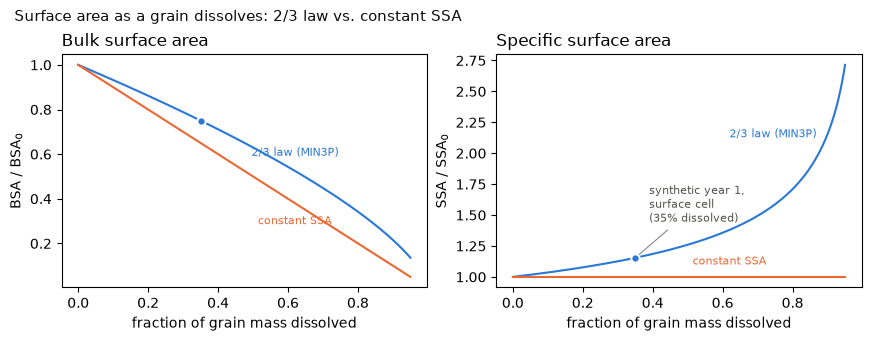

In [14]:
dissolved = np.linspace(0.0, 0.95, 200)
remaining = 1.0 - dissolved

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.3), constrained_layout=True)

for ax, (bsa_curve, ssa_curve, ylab, title) in zip(axes, [
    (remaining ** (2 / 3), remaining, "BSA / BSA$_0$", "Bulk surface area"),
    (remaining ** (-1 / 3), np.ones_like(remaining), "SSA / SSA$_0$", "Specific surface area"),
]):
    ax.plot(dissolved, bsa_curve, color=CAT["blue"])
    ax.plot(dissolved, ssa_curve, color=CAT["orange"])
    ax.set(xlabel="fraction of grain mass dissolved", ylabel=ylab)
    ax.set_title(title, loc="left")
    ax.set_axisbelow(True)

label_line(axes[0], 0.62, 0.38 ** (2 / 3), "2/3 law (MIN3P)", CAT["blue"],
           dx=0, dy=9, ha="center", va="bottom")
label_line(axes[0], 0.62, 0.38, "constant SSA", CAT["orange"],
           dx=0, dy=-9, ha="center", va="top")
label_line(axes[1], 0.90, 0.10 ** (-1 / 3), "2/3 law (MIN3P)", CAT["blue"],
           dx=-8, dy=0, ha="right", va="center")
label_line(axes[1], 0.62, 1.0, "constant SSA", CAT["orange"],
           dx=0, dy=7, ha="center", va="bottom")

# Where the synthetic year-1 surface cell lands
frac_gone = 1 - phi_end_y1[fi_min][-1] / rebuilt_phi[fi_min][-1]
for ax, val in zip(axes, [(1 - frac_gone) ** (2 / 3), (1 - frac_gone) ** (-1 / 3)]):
    ax.scatter([frac_gone], [val], s=36, color=CAT["blue"], zorder=5,
               edgecolor=SURFACE, linewidth=1.5)
axes[1].annotate(f"synthetic year 1,\nsurface cell\n({100 * frac_gone:.0f}% dissolved)",
                 xy=(frac_gone, (1 - frac_gone) ** (-1 / 3)), xytext=(10, 26),
                 textcoords="offset points", fontsize=8, color=INK["secondary"],
                 arrowprops=dict(arrowstyle="-", color=INK["muted"], linewidth=0.8))

fig.suptitle("Surface area as a grain dissolves: 2/3 law vs. constant SSA",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

### Applying year 2's rock, with and without tillage mixing

`mix_rule='homogeneous'` (the default) averages both volume fraction and bulk surface area over the plough layer, so the new year starts from a uniform profile. `mix_rule='none'` forces fresh rock to simply layer onto the existing distribution.

In [15]:
props_annual = feedstock_properties(forsterite, forsterite_density, app_rate_t_ha=1.0,
                                    till_depth_m=0.3)

variants = {
    rule: apply_feedstock(phi_end_y1, bsa_end_y1, ctrl_cols, props_annual, prof,
                          mix_mask=till, mix_rule=rule)
    for rule in ("homogeneous", "none")
}

# Conservation: mixing must not create or destroy feedstock mass or surface area
for rule, (p_new, b_new) in variants.items():
    dphi = p_new[fi_min][till].sum() / variants["none"][0][fi_min][till].sum() - 1
    dbsa = b_new[fi_srf][till].sum() / variants["none"][1][fi_srf][till].sum() - 1
    print(f"{rule:<12} layer-integrated  phi: {dphi:+.2e}   bsa: {dbsa:+.2e}")

assert np.isclose(variants["homogeneous"][0][fi_min][till].sum(),
                  variants["none"][0][fi_min][till].sum())
assert np.isclose(variants["homogeneous"][1][fi_srf][till].sum(),
                  variants["none"][1][fi_srf][till].sum())
print("\nhomogeneous mixing conserves both mass and surface area")

homogeneous  layer-integrated  phi: +2.22e-16   bsa: +0.00e+00
none         layer-integrated  phi: +0.00e+00   bsa: +0.00e+00

homogeneous mixing conserves both mass and surface area


In [16]:
# Cohort accounting at three depths, under homogeneous mixing
phi_y2, bsa_y2 = variants["homogeneous"]
ssa_end_y1 = implied_ssa(phi_end_y1, bsa_end_y1, ctrl_cols, FS, mineral_db)["forst-ph"]
ssa_y2 = implied_ssa(phi_y2, bsa_y2, ctrl_cols, FS, mineral_db)["forst-ph"]

depths_cm = [0, 10, 25]
rows = []
for d in depths_cm:
    k = np.argmin(np.abs((z.max() - z) - d / 100))
    rows.append({
        "depth_cm": d,
        "phi_start_y1": rebuilt_phi[fi_min][k], "bsa_start_y1": rebuilt_bsa[fi_srf][k],
        "phi_end_y1": phi_end_y1[fi_min][k], "bsa_end_y1": bsa_end_y1[fi_srf][k],
        "ssa_end_y1": ssa_end_y1[k],
        "phi_start_y2": phi_y2[fi_min][k], "bsa_start_y2": bsa_y2[fi_srf][k],
        "ssa_start_y2": ssa_y2[k],
    })

print(f"fresh-grain SSA: {props_annual.loc[0, 'ssa_m2_g']:.4f} m2/g\n")
pd.DataFrame(rows).set_index("depth_cm").T.round(6)

fresh-grain SSA: 0.3750 m2/g



depth_cm,0,10,25
phi_start_y1,0.001042,0.001042,0.001042
bsa_start_y1,1.250000,1.250000,1.250000
phi_end_y1,0.000677,0.000854,0.000973
bsa_end_y1,0.937963,1.095368,1.194286
ssa_end_y1,0.432906,0.400596,0.383647
phi_start_y2,0.000983,0.000983,0.000983
bsa_start_y2,1.239612,1.239612,1.239612
ssa_start_y2,0.394118,0.394118,0.394118


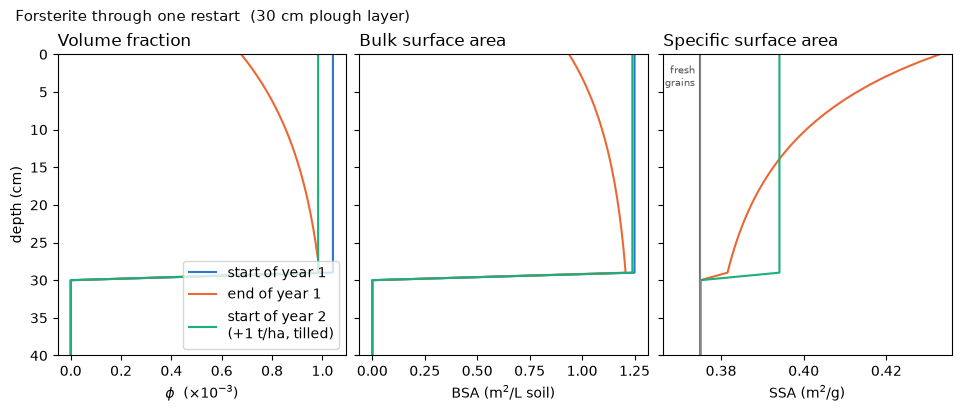

In [19]:
depth_cm = as_depth_cm(z)
stages = [
    ("start of year 1", rebuilt_phi, rebuilt_bsa, CAT["blue"]),
    ("end of year 1", phi_end_y1, bsa_end_y1, CAT["orange"]),
    ("start of year 2\n(+1 t/ha, tilled)", phi_y2, bsa_y2, CAT["aqua"]),
]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 4.0), sharey=True, constrained_layout=True)
for label, p_arr, b_arr, color in stages:
    ssa = implied_ssa(p_arr, b_arr, ctrl_cols, FS, mineral_db)["forst-ph"]
    axes[0].plot(p_arr[fi_min] * 1e3, depth_cm, color=color, label=label)
    axes[1].plot(b_arr[fi_srf], depth_cm, color=color, label=label)
    axes[2].plot(ssa, depth_cm, color=color, label=label)

axes[0].set(xlabel=r"$\phi$  (×10$^{-3}$)", ylabel="depth (cm)")
axes[1].set(xlabel="BSA (m$^2$/L soil)")
axes[2].set(xlabel="SSA (m$^2$/g)")
for ax, title in zip(axes, ["Volume fraction", "Bulk surface area", "Specific surface area"]):
    ax.set_title(title, loc="left")
    depth_axis(ax, max_depth_cm=40)

ssa_fresh_grain = props_annual.loc[0, "ssa_m2_g"]
axes[2].set_xlim(ssa_fresh_grain - 0.009, None)
axes[2].axvline(ssa_fresh_grain, color=INK["muted"], linewidth=0.8)
axes[2].annotate("fresh\ngrains", xy=(ssa_fresh_grain, 3), xytext=(-4, 0),
                 textcoords="offset points", fontsize=7.5, color=INK["secondary"],
                 ha="right", va="center")

axes[0].legend(loc="lower right")
fig.suptitle("Forsterite through one restart  (30 cm plough layer)",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

#### Homogenization check

The layer-integrated totals are identical (mixing conserves both). Confirms homogenization is just redistribution here.

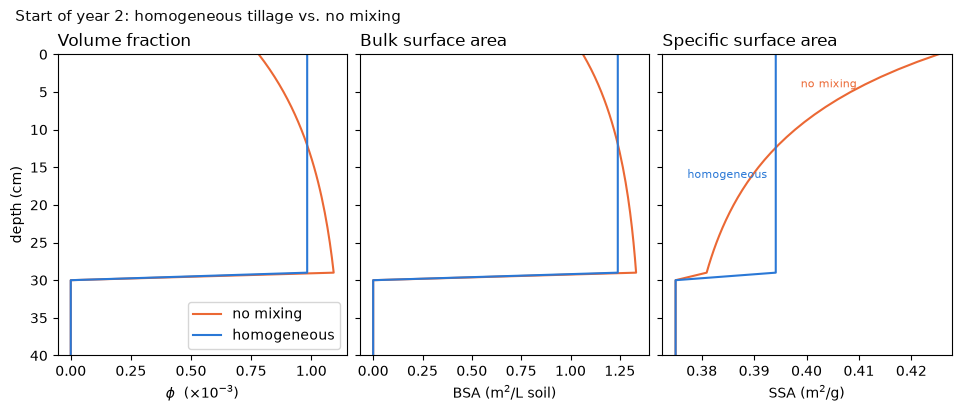

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(9.5, 4.0), sharey=True, constrained_layout=True)

styles = {"none": ("no mixing", CAT["orange"]), "homogeneous": ("homogeneous", CAT["blue"])}
for rule, (label, color) in styles.items():
    p_arr, b_arr = variants[rule]
    ssa = implied_ssa(p_arr, b_arr, ctrl_cols, FS, mineral_db)["forst-ph"]
    axes[0].plot(p_arr[fi_min] * 1e3, depth_cm, color=color, label=label)
    axes[1].plot(b_arr[fi_srf], depth_cm, color=color, label=label)
    axes[2].plot(ssa, depth_cm, color=color, label=label)

axes[0].set(xlabel=r"$\phi$  (×10$^{-3}$)", ylabel="depth (cm)")
axes[1].set(xlabel="BSA (m$^2$/L soil)")
axes[2].set(xlabel="SSA (m$^2$/g)")
for ax, title in zip(axes, ["Volume fraction", "Bulk surface area", "Specific surface area"]):
    ax.set_title(title, loc="left")
    depth_axis(ax, max_depth_cm=40)

# Direct-label in the SSA panel, at depths where the two rules are well separated
ssa_none = implied_ssa(*variants["none"], ctrl_cols, FS, mineral_db)["forst-ph"]
ssa_homo = implied_ssa(*variants["homogeneous"], ctrl_cols, FS, mineral_db)["forst-ph"]
k_none = np.argmin(np.abs(depth_cm - 4))
k_homo = np.argmin(np.abs(depth_cm - 16))
label_line(axes[2], ssa_none[k_none], depth_cm[k_none], "no mixing", CAT["orange"],
           dx=-6, ha="right")
label_line(axes[2], ssa_homo[k_homo], depth_cm[k_homo], "homogeneous", CAT["blue"],
           dx=-6, ha="right")

axes[0].legend(loc="lower right")
fig.suptitle("Start of year 2: homogeneous tillage vs. no mixing",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

Application timing comes from a schedule file rather than hard-coded lists (same pattern used for SCEPTER runs with `dust_ts_fn`). Schedule lists only the years something is applied; an absent year means no rock goes on. This lets us set up variable-rate schedules later one without much extra work.

In [21]:
def load_schedule(path, n_years):
    """Read an application schedule file into a per-year array of rates.

    Parameters
    ----------
    path : str or pathlib.Path
        CSV with columns `year` (1-indexed) and `rate_t_ha`. Lines beginning
        with `#` are comments. Only years with an application need a row.
    n_years : int
        Length of the run. Years beyond the last scheduled application get 0.

    Returns
    -------
    numpy.ndarray
        Application rate (t/ha) for each year, length `n_years`. Multiple rows
        for the same year are summed, so split applications work.
    """
    sched = pd.read_csv(path, comment="#")
    missing = {"year", "rate_t_ha"} - set(sched.columns)
    if missing:
        raise ValueError(f"{path} is missing required column(s): {sorted(missing)}")

    rates = np.zeros(n_years, dtype=float)
    for _, row in sched.iterrows():
        year = int(row["year"])
        if not 1 <= year <= n_years:
            raise ValueError(f"{path}: year {year} is outside a {n_years}-year run")
        rates[year - 1] += float(row["rate_t_ha"])
    return rates


def props_for_schedule(rates, feedstock, density_g_cm3, **kwargs):
    """Pre-compute feedstock properties for each distinct non-zero rate in a schedule."""
    return {rate: feedstock_properties(feedstock, density_g_cm3, app_rate_t_ha=rate, **kwargs)
            for rate in sorted({r for r in rates if r > 0})}


for name in ["pulse_10tha", "annual_1tha", "control_none"]:
    print(f"{name:<14} {load_schedule(SCHEDULES / f'{name}.csv', 10)}")

pulse_10tha    [10.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
annual_1tha    [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
control_none   [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [22]:
def chain_years(app_rates, props_by_rate, profile, mix_mask, phi0, bsa0, columns, minerals,
                z, scheme="additive", mix_rule=DEFAULT_MIX_RULE,
                till_without_application=False, ssa_m2_g=None,
                mineral_db=None, surface_loss=0.35, e_folding_m=0.15):
    """Run a synthetic multi-year chain under one bookkeeping scheme and mixing rule.

    `till_without_application` controls whether the plough layer is still mixed in
    years with no application. Defaults to False -- no application, no tillage.
    """
    phi, bsa = phi0.copy(), bsa0.copy()
    idx = [list(columns).index(m) for m in minerals]
    history = []

    for year, rate in enumerate(app_rates, start=1):
        if rate > 0:
            phi, bsa = apply_feedstock(phi, bsa, columns, props_by_rate[rate], profile,
                                       mix_mask=mix_mask, mix_rule=mix_rule)
        elif till_without_application:
            phi, bsa = till_soil(phi, bsa, columns, minerals, mix_mask, mix_rule=mix_rule)
        history.append({"year": year, "phi": phi[idx[0]].copy(), "bsa": bsa[idx[0]].copy()})

        phi_start, bsa_start = phi.copy(), bsa.copy()
        phi = synthetic_dissolution(phi, z, columns, minerals,
                                    surface_loss=surface_loss, e_folding_m=e_folding_m)
        if scheme == "additive":
            bsa = advance_surface_area(bsa_start, phi_start, phi, columns, minerals)
        elif scheme == "constant_ssa":
            bsa = bsa.copy()
            for i, mineral in zip(idx, minerals):
                rho = mineral_db[mineral]["density_g_cm3"]
                bsa[i] = ssa_m2_g * rho * 1e3 * phi[i]
        else:
            raise ValueError(scheme)

    return pd.DataFrame(history)


rates = load_schedule(SCHEDULES / "annual_1tha.csv", n_years=10)
props_by_rate = props_for_schedule(rates, forsterite, forsterite_density, till_depth_m=0.3)
ssa_fresh = props_annual.loc[0, "ssa_m2_g"]

cases = {
    "additive + homogeneous": dict(scheme="additive", mix_rule="homogeneous"),
    "additive + no mixing": dict(scheme="additive", mix_rule="none"),
    "constant_ssa + homogeneous": dict(scheme="constant_ssa", mix_rule="homogeneous"),
}
runs = {
    name: chain_years(rates, props_by_rate, prof, till, ctrl_min, ctrl_surf, ctrl_cols,
                      FS, z, ssa_m2_g=ssa_fresh, mineral_db=mineral_db, **kw)
    for name, kw in cases.items()
}

summary = pd.DataFrame({
    name: [df.loc[y, "bsa"][till].sum() for y in range(10)] for name, df in runs.items()
}, index=pd.Index(range(1, 11), name="year"))
summary["additive vs constant_ssa (%)"] = 100 * (
    summary["additive + homogeneous"] / summary["constant_ssa + homogeneous"] - 1)
summary["homogeneous vs none (%)"] = 100 * (
    summary["additive + homogeneous"] / summary["additive + no mixing"] - 1)
summary.round(3)

,additive + homogeneous,additive + no mixing,constant_ssa + homogeneous,additive vs constant_ssa (%),homogeneous vs none (%)
year,,,,,
1,3.750,3.750,3.750,0.000,0.000
2,7.094,7.094,6.913,2.609,0.000
3,10.075,10.090,9.582,5.150,-0.145
4,12.734,12.787,11.833,7.614,-0.416
5,15.105,15.226,13.732,9.995,-0.795
6,17.219,17.439,15.334,12.290,-1.264
7,19.104,19.456,16.686,14.492,-1.808
8,20.785,21.299,17.826,16.599,-2.413
9,22.284,22.989,18.788,18.607,-3.068


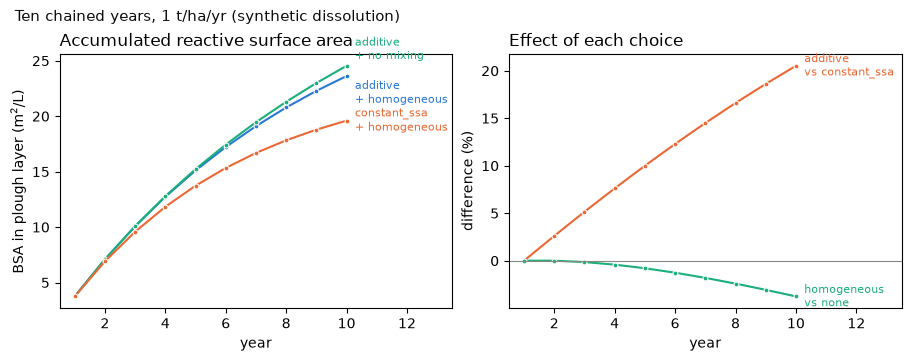

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.5), constrained_layout=True)

colors = {"additive + homogeneous": CAT["blue"],
          "additive + no mixing": CAT["aqua"],
          "constant_ssa + homogeneous": CAT["orange"]}
years = summary.index.values

label_dy = {"additive + no mixing": 12, "additive + homogeneous": -12,
            "constant_ssa + homogeneous": 0}
for name, color in colors.items():
    axes[0].plot(years, summary[name], color=color, marker="o", markersize=3.5,
                 markeredgecolor=SURFACE, markeredgewidth=0.8)
    label_line(axes[0], years[-1], summary[name].iloc[-1], name.replace(" + ", "\n+ "),
               color, dx=6, dy=label_dy[name], va="center")
axes[0].set(xlabel="year", ylabel="BSA in plough layer (m$^2$/L)", xlim=(0.5, 13.5))
axes[0].set_title("Accumulated reactive surface area", loc="left")

for col, color in [("additive vs constant_ssa (%)", CAT["orange"]),
                   ("homogeneous vs none (%)", CAT["aqua"])]:
    axes[1].plot(years, summary[col], color=color, marker="o", markersize=3.5,
                 markeredgecolor=SURFACE, markeredgewidth=0.8)
    label_line(axes[1], years[-1], summary[col].iloc[-1],
               col.replace(" (%)", "").replace(" vs ", "\nvs "), color, dx=6)
axes[1].axhline(0, color=INK["muted"], linewidth=0.8)
axes[1].set(xlabel="year", ylabel="difference (%)", xlim=(0.5, 13.5))
axes[1].set_title("Effect of each choice", loc="left")

for ax in axes:
    ax.set_axisbelow(True)

fig.suptitle("Ten chained years, 1 t/ha/yr (synthetic dissolution)",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

#### Tillage in years with no application

`till_without_application` (default `False`) decides whether the plough layer is still mixed in a year when no rock goes on. Tillage (homogenization) can increase weathering by shuttling rock up to the faster-dissolving depths that are more rapidly losing rock. 

In [25]:
pulse_rates = load_schedule(SCHEDULES / "pulse_10tha.csv", n_years=10)
pulse_props = props_for_schedule(pulse_rates, forsterite, forsterite_density, till_depth_m=0.3)

pulse = {
    label: chain_years(pulse_rates, pulse_props, prof, till, ctrl_min, ctrl_surf,
                       ctrl_cols, FS, z, till_without_application=flag,
                       mineral_db=mineral_db)
    for label, flag in [("no tillage (default)", False), ("tilled every year", True)]
}

pulse_summary = pd.DataFrame({
    name: [df.loc[y, "bsa"][till].sum() for y in range(10)] for name, df in pulse.items()
}, index=pd.Index(range(1, 11), name="year"))
pulse_summary["difference (%)"] = 100 * (
    pulse_summary["tilled every year"] / pulse_summary["no tillage (default)"] - 1)
pulse_summary.round(3)

,no tillage (default),tilled every year,difference (%)
year,,,
1,37.500,37.500,0.000
2,33.438,33.438,0.000
3,29.963,29.817,-0.490
4,26.973,26.587,-1.431
5,24.385,23.707,-2.779
6,22.133,21.140,-4.489
7,20.163,18.850,-6.513
8,18.431,16.808,-8.804
9,16.900,14.988,-11.315


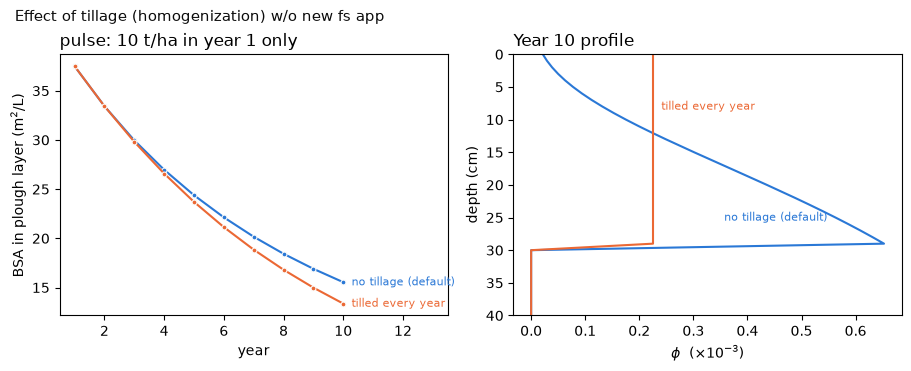

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)

pulse_colors = {"no tillage (default)": CAT["blue"], "tilled every year": CAT["orange"]}
for name, color in pulse_colors.items():
    axes[0].plot(pulse_summary.index, pulse_summary[name], color=color,
                 marker="o", markersize=3.5, markeredgecolor=SURFACE, markeredgewidth=0.8)
    label_line(axes[0], 10, pulse_summary[name].iloc[-1], name, color, dx=6)
axes[0].set(xlabel="year", ylabel="BSA in plough layer (m$^2$/L)", xlim=(0.5, 13.5))
axes[0].set_title("pulse: 10 t/ha in year 1 only", loc="left")
axes[0].set_axisbelow(True)

# End-state depth profiles: tillage keeps redistributing what is left
label_depth = {"no tillage (default)": 25, "tilled every year": 8}
for name, color in pulse_colors.items():
    axes[1].plot(pulse[name].loc[9, "phi"] * 1e3, depth_cm, color=color)
    k = np.argmin(np.abs(depth_cm - label_depth[name]))
    label_line(axes[1], pulse[name].loc[9, "phi"][k] * 1e3, depth_cm[k], name, color,
               dx=(-6 if "no" in name else 6), ha=("right" if "no" in name else "left"))
axes[1].set(xlabel=r"$\phi$  (×10$^{-3}$)", ylabel="depth (cm)")
axes[1].set_title("Year 10 profile", loc="left")
depth_axis(axes[1], max_depth_cm=40)

fig.suptitle("Effect of tillage (homogenization) w/o new fs app",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

---
## 7. Multi-mineral feedstock

Nothing in S3–S6 is forsterite-specific. Here we test a demo four-mineral basalt.

Note: this is for demonstration purposes only — without these minerals represented in the spinup we can't add them in at the ERW run. 

In [30]:
basalt, basalt_density = load_feedstock(FEEDSTOCKS / "basalt_demo.csv", mineral_db,
                                        default_diameter_um=50.0)
print(f"derived bulk density: {basalt_density:.4f} g/cm3")

basalt_props = feedstock_properties(basalt, basalt_density, app_rate_t_ha=10.0,
                                    till_depth_m=0.3)
print(f"volume fractions sum to {basalt_props['vol_frac_in_feedstock'].sum():.12f}\n")
basalt_props[["mineral", "wt_frac", "density_g_cm3", "roughness_factor", "ssa_m2_g",
              "vol_frac_in_feedstock", "vol_frac_in_soil", "bsa_m2_L"]].round(6)

derived bulk density: 2.9759 g/cm3
volume fractions sum to 1.000000000000



,mineral,wt_frac,density_g_cm3,roughness_factor,ssa_m2_g,vol_frac_in_feedstock,vol_frac_in_soil,bsa_m2_L
0,anorthite-ph,0.40,2.76,10.0,0.434783,0.431292,0.000483,0.579710
1,augite-ph,0.35,3.30,10.0,0.363636,0.315627,0.000354,0.424242
2,forst-ph,0.15,3.20,10.0,0.375000,0.139496,0.000156,0.187500
3,albite-ph,0.10,2.62,10.0,0.458015,0.113585,0.000127,0.152672


In [31]:
# The guard fires because these minerals have no column in the Cecil arrays.
try:
    apply_feedstock(ctrl_min, ctrl_surf, ctrl_cols, basalt_props, prof, mix_mask=till)
except KeyError as err:
    print("KeyError (expected):", err)

# Exercise the multi-mineral path on a synthetic array that does have the columns.
basalt_minerals = list(basalt_props["mineral"])
demo_cols = ["x", "y", "z"] + basalt_minerals
demo_phi = np.full((len(demo_cols), len(z)), PHI_FLOOR)
demo_phi[demo_cols.index("z")] = z
demo_bsa = np.zeros_like(demo_phi)
demo_bsa[demo_cols.index("z")] = z

demo_phi_1, demo_bsa_1 = apply_feedstock(demo_phi, demo_bsa, demo_cols, basalt_props,
                                         prof, mix_mask=till)

# Dissolve each mineral at a different rate, then re-apply
demo_phi_end = demo_phi_1.copy()
for m, loss in zip(basalt_minerals, [0.10, 0.15, 0.40, 0.05]):
    demo_phi_end = synthetic_dissolution(demo_phi_end, z, demo_cols, [m], surface_loss=loss)

demo_bsa_end = advance_surface_area(demo_bsa_1, demo_phi_1, demo_phi_end,
                                    demo_cols, basalt_minerals)
demo_phi_2, demo_bsa_2 = apply_feedstock(demo_phi_end, demo_bsa_end, demo_cols,
                                         basalt_props, prof, mix_mask=till)

ssa_1 = implied_ssa(demo_phi_1, demo_bsa_1, demo_cols, basalt_minerals, mineral_db)
ssa_end = implied_ssa(demo_phi_end, demo_bsa_end, demo_cols, basalt_minerals, mineral_db)
ssa_2 = implied_ssa(demo_phi_2, demo_bsa_2, demo_cols, basalt_minerals, mineral_db)

surface = -1
pd.DataFrame({
    "phi_applied_y1": [demo_phi_1[demo_cols.index(m)][surface] for m in basalt_minerals],
    "phi_end_y1": [demo_phi_end[demo_cols.index(m)][surface] for m in basalt_minerals],
    "phi_start_y2": [demo_phi_2[demo_cols.index(m)][surface] for m in basalt_minerals],
    "ssa_applied_y1": [ssa_1[m][surface] for m in basalt_minerals],
    "ssa_end_y1": [ssa_end[m][surface] for m in basalt_minerals],
    "ssa_start_y2": [ssa_2[m][surface] for m in basalt_minerals],
}, index=pd.Index(basalt_minerals, name="mineral")).round(6)

KeyError (expected): "feedstock minerals absent from the mineral arrays: ['anorthite-ph', 'augite-ph', 'albite-ph']. They must be declared in the 'minerals' block of the .dat deck."


,phi_applied_y1,phi_end_y1,phi_start_y2,ssa_applied_y1,ssa_end_y1,ssa_start_y2
mineral,,,,,,
anorthite-ph,0.000483,0.000435,0.000945,0.434783,0.450323,0.438028
augite-ph,0.000354,0.000301,0.000683,0.363636,0.383879,0.367711
forst-ph,0.000156,0.000094,0.000285,0.375000,0.444611,0.386162
albite-ph,0.000127,0.000121,0.000252,0.458015,0.465913,0.459723


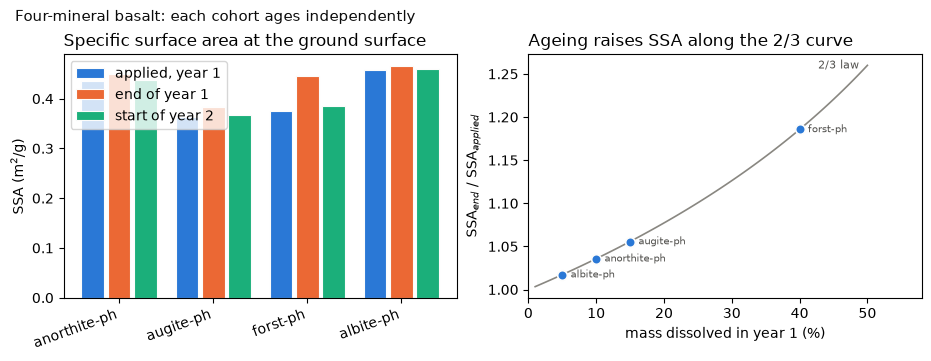

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5), constrained_layout=True)

stage_colors = [("applied, year 1", ssa_1, CAT["blue"]),
                ("end of year 1", ssa_end, CAT["orange"]),
                ("start of year 2", ssa_2, CAT["aqua"])]
xpos = np.arange(len(basalt_minerals))
width = 0.24

for k, (label, ssa_dict, color) in enumerate(stage_colors):
    vals = [ssa_dict[m][surface] for m in basalt_minerals]
    axes[0].bar(xpos + (k - 1) * 0.28, vals, width, color=color, label=label,
                edgecolor=SURFACE, linewidth=0.8)
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(basalt_minerals, rotation=20, ha="right")
axes[0].set(ylabel="SSA (m$^2$/g)")
axes[0].set_title("Specific surface area at the ground surface", loc="left")
axes[0].legend(loc="upper left", ncol=1)
axes[0].set_axisbelow(True)

# SSA gain from ageing, against how much of each mineral dissolved
loss = [1 - demo_phi_end[demo_cols.index(m)][surface] / demo_phi_1[demo_cols.index(m)][surface]
        for m in basalt_minerals]
gain = [ssa_end[m][surface] / ssa_1[m][surface] for m in basalt_minerals]
axes[1].scatter(np.array(loss) * 100, gain, s=48, color=CAT["blue"],
                edgecolor=SURFACE, linewidth=1.2, zorder=5)
grid_loss = np.linspace(0.01, 0.5, 100)
axes[1].plot(grid_loss * 100, (1 - grid_loss) ** (-1 / 3), color=INK["muted"], linewidth=1.2)
label_line(axes[1], 50, (1 - 0.5) ** (-1 / 3), "2/3 law", INK["secondary"], dx=-6, ha="right")
for m, x, y in zip(basalt_minerals, np.array(loss) * 100, gain):
    axes[1].annotate(m, xy=(x, y), xytext=(6, -2), textcoords="offset points",
                     fontsize=7.5, color=INK["secondary"])
axes[1].set(xlabel="mass dissolved in year 1 (%)", ylabel="SSA$_{end}$ / SSA$_{applied}$",
            xlim=(0, 58))
axes[1].set_title("Ageing raises SSA along the 2/3 curve", loc="left")
axes[1].set_axisbelow(True)

fig.suptitle("Four-mineral basalt: each cohort ages independently",
             fontsize=11, color=INK["primary"], x=0.01, ha="left")
plt.show()

### One caveat for multi-mineral feedstocks

We want to give feedstock minerals their own name, especially if a feedstock mineral is also a soil mineral since they have different surface areas and SA evolutions.